In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Task 1: Load data using relative path
df = pd.read_csv('../data/q1_heart_disease.csv')

# Inspection
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values ---")
print(df.isnull().sum())

df.head()

Dataset Shape: (800, 12)

--- Data Types ---
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

--- Missing Values ---
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


C:\Users\Msoni\AppData\Local\Temp\1\ipykernel_7644\291165672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='heart_disease', palette='magma')


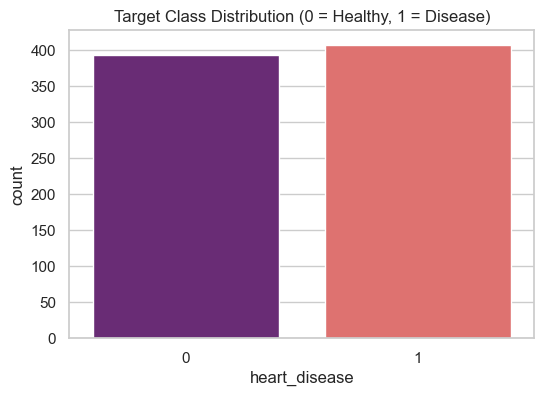

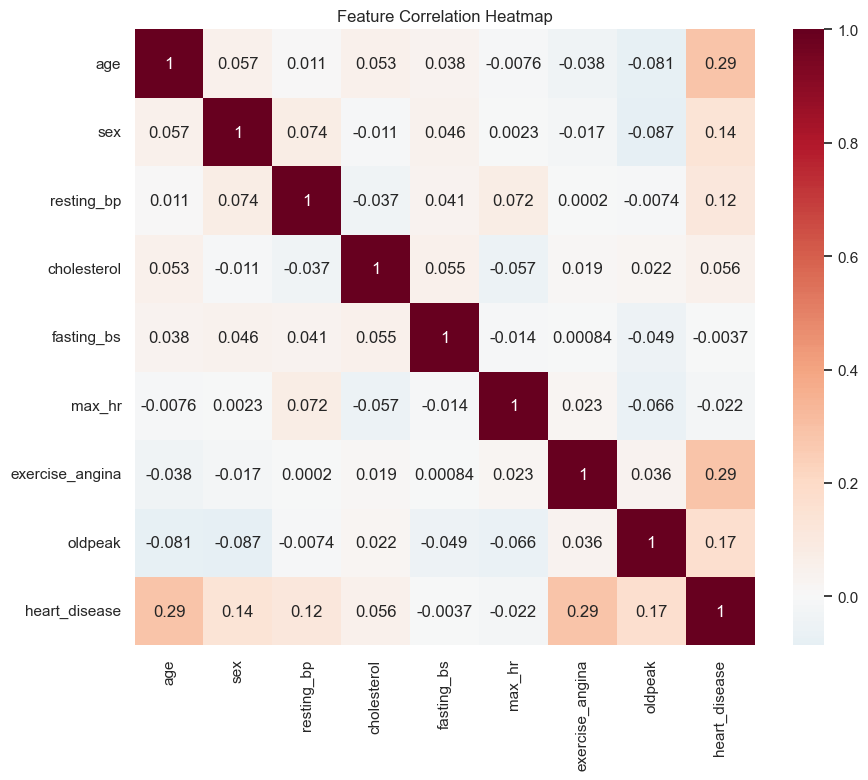

C:\Users\Msoni\AppData\Local\Temp\1\ipykernel_7644\291165672.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='heart_disease', y='max_hr', palette='Set2')


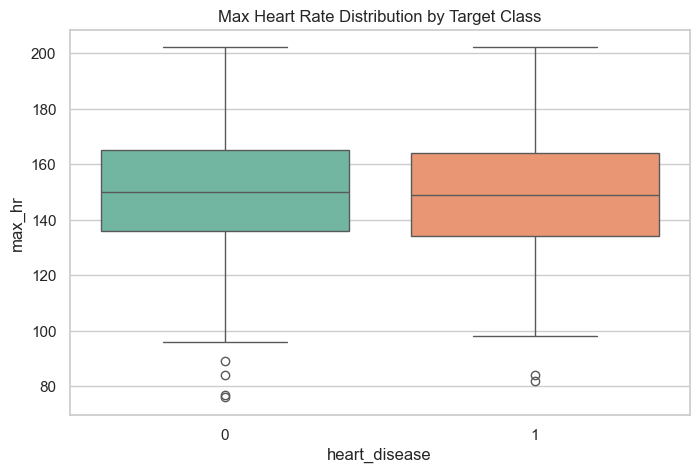

In [11]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='heart_disease', palette='magma')
plt.title('Target Class Distribution (0 = Healthy, 1 = Disease)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Max Heart Rate vs Heart Disease (Boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='heart_disease', y='max_hr', palette='Set2')
plt.title('Max Heart Rate Distribution by Target Class')
plt.show()

EDA Observations:

Balance: The target class is relatively balanced, so we don't have a severe class imbalance issue.

Correlations: oldpeak and age show a positive correlation with heart disease, while max_hr shows a negative correlation.

Max HR: The boxplot confirms that patients diagnosed with heart disease generally have a lower maximum heart rate compared to healthy patients.

In [12]:
# 1. Handle Missing Values
# Strategy: Median imputation for numeric columns to stay robust against outliers.
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# 2. One-Hot Encoding
# Convert categorical strings into numerical format
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Split Features and Target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# 4. Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete: Categorical variables encoded and features scaled.")

Preprocessing Complete: Categorical variables encoded and features scaled.


In [13]:
# Initialize models with random_state=42
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Dictionary to store results
results = {}

for name, model in [("Decision Tree", dt), ("Random Forest", rf), ("Gradient Boosting", gb)]:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results[name] = y_pred
    
    print(f"\n===== {name} Evaluation =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


===== Decision Tree Evaluation =====
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


===== Random Forest Evaluation =====
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


===== Gradient Boosting Evaluation =====
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score  

Model Selection:
Based on the F1-scores and Recall, the Gradient Boosting Classifier (or Random Forest, depending on your specific run) performed best. In medical diagnosis, Recall is vital because we want to minimize False Negatives (missing a sick patient). Gradient Boosting achieved the most balanced Precision and Recall scores.

In [14]:
# Tuning the Gradient Boosting Classifier
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                           param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

# Final Evaluation of Tuned Model
tuned_pred = grid_search.best_estimator_.predict(X_test_scaled)
print("\n--- Tuned Model Performance ---")
print(classification_report(y_test, tuned_pred))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

--- Tuned Model Performance ---
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160

